### 0. 라이브러리 import 및 데이터 불러오기

In [465]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRICE_FILE = "2000_2026_코스피코스닥_수정주가_일별_비영업일제외.csv"
KOSPI200_VOLUME_FILE = "2000_2026_코스피200_일별_거래량_비영업일제외.csv"
MCAP_FILE = "2000_2026_코스피코스닥_시가총액_일별_비영업일제외.csv"
FACTOR_FILE = "2000_2026_KOSPI200, SMB, HML, MOM_수정종가_91CD_알별_비영업일제외.csv"

price = pd.read_csv(PRICE_FILE, index_col=0, parse_dates=True).sort_index()
kospi200_volume = pd.read_csv(KOSPI200_VOLUME_FILE, index_col=0, parse_dates=True).sort_index()
mcap = pd.read_csv(MCAP_FILE, index_col=0, parse_dates=True).sort_index()
factor = pd.read_csv(FACTOR_FILE, index_col=0, parse_dates=True).sort_index()

### 1. 초기 작업 및 설정

In [466]:
# 일별 단순 수익률, 로그 수익률 생성
ret = price.pct_change(fill_method=None).iloc[1:]
logret = np.log(price / price.shift(1)).iloc[1:]

def winsorize_df(df, lower=0.005, upper=0.995):
    lower_q = df.quantile(lower)
    upper_q = df.quantile(upper)
    return df.clip(lower=lower_q, upper=upper_q, axis=1)

# factor 설정 (일별 변화로)
rf_col = "CD(91)" if "CD(91)" in factor.columns else "91CD"
factor_ret = factor[["KOSPI200", "SMB", "HML", "MOM"]].pct_change(fill_method=None).iloc[1:]
rf = ((1 + factor[rf_col].iloc[1:] / 100) ** (1 / 252)) - 1  # 연금리 일금리변환

# raw data 따로 분리 (윈저라이징 전 원본 보관)
ret_raw = ret.copy()
logret_raw = logret.copy()
factor_ret_raw = factor_ret.copy()

# 극단치 완화
ret = winsorize_df(ret)
logret = winsorize_df(logret)
factor_ret = winsorize_df(factor_ret)

factor_ret["RF"] = rf
factor_ret["MKT"] = factor_ret["KOSPI200"] - factor_ret["RF"]
ff4 = factor_ret[["MKT", "SMB", "HML", "MOM"]]

# 회귀에 사용할 공통 거래일 정렬
common_index = ret.index.intersection(ff4.index)
ret = ret.loc[common_index]
logret = logret.loc[common_index]
rf = rf.loc[common_index]
ff4 = ff4.loc[common_index]
excess_ret = ret.sub(rf, axis=0)
ret_raw = ret_raw.loc[common_index]
logret_raw = logret_raw.loc[common_index]
factor_ret_raw = factor_ret_raw.loc[common_index]

In [467]:
# 베타 추정 설정
BETA_WINDOW = 252  # 메인 사양: 1년(약 252거래일)
MIN_OBS = int(BETA_WINDOW * 0.75)

# 60일 평균 거래대금
adv60 = trading_value.rolling(60).mean()

# 최근 60일 실제 거래일
trade_days_60 = trading_value.rolling(60).count()

# 월말 리밸런싱 날짜: 각 월의 실제 마지막 거래일 사용
rebalance_dates = pd.DatetimeIndex(price.index.to_series().groupby(price.index.to_period("M")).last())

# 베타 룩백이 가능한 시점부터만 분석
eligible_rebalance_dates = rebalance_dates[rebalance_dates.isin(excess_ret.index)]
analysis_start_date = eligible_rebalance_dates[eligible_rebalance_dates >= excess_ret.index[BETA_WINDOW - 1]][0]
rebalance_dates = eligible_rebalance_dates[eligible_rebalance_dates >= analysis_start_date]

In [468]:
# 월말 데이터
monthly_price = price.loc[rebalance_dates]
monthly_adv60 = adv60.loc[rebalance_dates]
monthly_trade_days_60 = trade_days_60.loc[rebalance_dates]
monthly_mcap = mcap.loc[rebalance_dates]

### 2. 필터링

In [469]:
# 1500원 미만 동전주 제거
price_filter = monthly_price >= 1500

# 최근 거래 60일 중 50일 미만 종목 제거
trade_days_filter = monthly_trade_days_60 >= 50

# 거래대금 하위 20% 제거
adv_rank_filter = monthly_adv60.rank(axis=1, pct=True) > 0.20

# 시가총액 하위 10% 제거
mcap_rank_filter = monthly_mcap.rank(axis=1, pct=True) > 0.10

# 상장 후 베타 룩백 창 이상 지난 종목만 사용
trading_day_number = pd.Series(np.arange(len(price.index)), index=price.index)
first_valid_date = price.apply(pd.Series.first_valid_index)
first_valid_day_number = first_valid_date.map(trading_day_number)
rebalance_day_number = trading_day_number.loc[rebalance_dates]
listing_age = rebalance_day_number.to_numpy()[:, None] - first_valid_day_number.to_numpy()[None, :] + 1
monthly_listing_days = pd.DataFrame(listing_age, index=rebalance_dates, columns=price.columns)
listing_filter = monthly_listing_days >= BETA_WINDOW

# 필터 합치기
basic_filter = (
    price_filter
    & trade_days_filter
    & adv_rank_filter
    & mcap_rank_filter
    & listing_filter
)
basic_filter.loc[basic_filter.index[0]].head()

삼성전자          True
SK하이닉스        True
현대차           True
LG에너지솔루션     False
한화에어로스페이스     True
Name: 2002-01-31 00:00:00, dtype: bool

In [470]:
def fit_ols_numpy(y, x, min_obs=MIN_OBS):
    valid = np.isfinite(y) & np.isfinite(x).all(axis=1)
    nobs = int(valid.sum())
    if nobs < min_obs:
        return None

    X = np.column_stack([np.ones(nobs), x[valid]])
    y_valid = y[valid]
    dof = nobs - X.shape[1]
    if dof <= 0:
        return None

    xtx = X.T @ X
    xty = X.T @ y_valid
    if (not np.isfinite(xtx).all()) or (not np.isfinite(xty).all()):
        return None

    try:
        xtx_inv = np.linalg.inv(xtx)
    except np.linalg.LinAlgError:
        return None

    params = xtx_inv @ xty
    resid = y_valid - X @ params
    sigma2 = (resid @ resid) / dof
    if not np.isfinite(sigma2):
        return None
    se = np.sqrt(np.diag(xtx_inv) * sigma2)
    return params, se, nobs

In [471]:
# 베타 담을 데이터프레임 생성
beta_mkt = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_smb = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_hml = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_mom = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_se = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_t = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)

In [472]:
# FF4 rolling beta + beta se, t-stat 구하기
for dt in rebalance_dates:
    if dt not in excess_ret.index or dt not in ff4.index:
        continue

    end_idx = excess_ret.index.get_loc(dt)
    start_idx = end_idx - (BETA_WINDOW - 1)

    if start_idx < 0:
        continue

    candidate_mask = basic_filter.loc[dt].fillna(False)
    candidate_cols = candidate_mask.index[candidate_mask]
    if len(candidate_cols) == 0:
        continue

    window_index = excess_ret.index[start_idx:end_idx+1]
    y_window = excess_ret.loc[window_index, candidate_cols]
    x_values = ff4.loc[window_index].to_numpy(dtype=float)

    for col in candidate_cols:
        result = fit_ols_numpy(y_window[col].to_numpy(dtype=float), x_values)
        if result is None:
            continue

        params, se, nobs = result
        beta_mkt.loc[dt, col] = params[1]
        beta_smb.loc[dt, col] = params[2]
        beta_hml.loc[dt, col] = params[3]
        beta_mom.loc[dt, col] = params[4]
        beta_se.loc[dt, col] = se[1]
        if se[1] > 0:
            beta_t.loc[dt, col] = params[1] / se[1]

In [473]:
# |t-stat| 하위 20% 제거
beta_t_filter = beta_t.abs().rank(axis=1, pct=True) > 0.20
final_filter = basic_filter & beta_t_filter

In [474]:
beta_mkt_raw = beta_mkt.copy()
beta_smb_raw = beta_smb.copy()
beta_hml_raw = beta_hml.copy()
beta_mom_raw = beta_mom.copy()
beta_se_raw = beta_se.copy()
beta_t_raw = beta_t.copy()

beta_mkt = beta_mkt.where(final_filter)
beta_smb = beta_smb.where(final_filter)
beta_hml = beta_hml.where(final_filter)
beta_mom = beta_mom.where(final_filter)
beta_se = beta_se.where(final_filter)
beta_t = beta_t.where(final_filter)

In [475]:
beta_mkt.head()

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,HD현대중공업,기아,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2002-01-31,1.236518,1.781622,1.209114,NaN,1.293537,NaN,NaN,NaN,NaN,0.933615,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-02-28,1.242387,1.762264,1.191645,NaN,1.295115,NaN,NaN,NaN,NaN,0.918960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-03-29,1.238706,1.763294,1.155565,NaN,1.278358,NaN,NaN,NaN,NaN,0.893113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-04-30,1.227585,1.781614,1.142855,NaN,1.318357,NaN,NaN,NaN,NaN,0.889345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-05-31,1.259492,1.815885,1.181957,NaN,1.341459,NaN,NaN,NaN,NaN,0.946718,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. 결과 검증

아래 표들은 `head()`보다 훨씬 직접적으로 결과가 정상인지 확인할 수 있게 도와준다.

이 파트에서 확인하려는 핵심은 세 가지다.

1. 월별로 충분한 수의 종목에 대해 베타가 계산되었는가
2. `t-stat` 필터가 실제로 종목을 걸러내고 있는가
3. 최종적으로 남은 `beta_mkt`, `beta_t` 값의 분포가 상식적인가

참고로 `describe()` 결과의 `count`는 종목 수가 아니라 해당 열에서 결측치가 아닌 **월 수**를 뜻한다. 예를 들어 `count = 291`이면, 그 값이 계산된 월이 총 291개라는 의미다.

현재 메인 사양은 `BETA_WINDOW = 252`, `MIN_OBS = 189`이며, `504`일은 robustness check 용으로 다시 돌려 비교할 수 있다.

#### 3-1. 월별 종목 수와 월별 중앙 `t-stat` 점검

이 표는 월별로 베타가 얼마나 계산되었는지와, 계산된 베타의 신뢰도가 어느 정도인지 요약한다.

열 설명:

- `beta_count_before_t`: `t-stat` 필터를 적용하기 전에 회귀가 실제로 계산된 종목 수
- `final_count`: 최종 필터까지 통과한 종목 수
- `median_beta_t_before_t`: 그 달에 계산된 `MKT beta t-stat`의 중앙값

해석 팁:

- `beta_count_before_t`가 너무 작으면 유니버스가 지나치게 좁거나 회귀 조건이 너무 빡센 것일 수 있다.
- `final_count`가 `beta_count_before_t`보다 꽤 작으면 `t-stat` 필터가 실제로 종목을 제거하고 있다는 뜻이다.
- `median_beta_t_before_t`가 높을수록 시장베타가 안정적으로 추정된 종목이 많다는 뜻이다.
- `tail(12)`는 최근 12개월의 상태를 빠르게 점검할 때 유용하다.

In [476]:
# 월별 계산/필터 통과 종목 수 요약
print("BETA_WINDOW:", BETA_WINDOW)
print("MIN_OBS:", MIN_OBS)
print("analysis_start_date:", analysis_start_date)

diagnostics = pd.DataFrame({
    "beta_count_before_t": beta_mkt_raw.notna().sum(axis=1),
    "final_count": final_filter.sum(axis=1),
    "median_beta_t_before_t": beta_t_raw.median(axis=1),
})

display(diagnostics.describe())
display(diagnostics.tail(12))

analysis_start_date: 2002-01-31 00:00:00


,beta_count_before_t,final_count,median_beta_t_before_t
count,291.000000,291.000000,291.000000
mean,1175.786942,941.013746,8.300120
std,319.787617,255.833162,2.075399
min,564.000000,452.000000,4.894092
25%,968.000000,774.500000,6.545626
50%,1154.000000,924.000000,8.267660
75%,1436.500000,1149.500000,9.869414
max,1683.000000,1347.000000,12.479021


,beta_count_before_t,final_count,median_beta_t_before_t
Date,,,
2025-04-30,1635,1308,8.273155
2025-05-30,1634,1308,8.267660
2025-06-30,1635,1308,8.463843
2025-07-31,1640,1312,8.515820
2025-08-29,1643,1315,8.524759
2025-09-30,1655,1324,8.696082
2025-10-31,1638,1311,8.609408
2025-11-28,1630,1304,8.681917
2025-12-30,1658,1327,8.574744


#### 3-2. 최종 베타와 `t-stat` 분포 점검

이 셀은 최종 필터 적용 후 남은 전체 표본의 분포를 확인한다.

출력 설명:

- `beta_mkt.stack().describe()`: 모든 월, 모든 종목의 최종 시장베타 분포 요약
- `beta_t.stack().describe()`: 모든 월, 모든 종목의 최종 `MKT beta t-stat` 분포 요약
- 히스토그램: `beta_mkt`가 어느 구간에 많이 몰려 있는지 시각적으로 확인

해석 팁:

- `beta_mkt`의 평균이나 중앙값이 극단적으로 크거나 작지 않은지 본다.
- `beta_mkt`의 `min`, `max`가 지나치게 튀면 일부 종목 회귀가 불안정한 것일 수 있다.
- `beta_t`의 중앙값이 너무 낮으면 회귀 신뢰도가 약하다는 신호일 수 있다.
- 히스토그램이 한쪽으로 너무 길게 늘어지면 이상치 점검이 필요할 수 있다.

count    273835.000000
mean          1.076576
std           0.303901
min          -1.051194
25%           0.864432
50%           1.075053
75%           1.281075
max           2.910012
dtype: float64

count    273835.000000
mean          9.474021
std           3.602470
min          -8.802931
25%           6.798096
50%           8.845916
75%          11.482854
max          43.006243
dtype: float64

<Axes: >

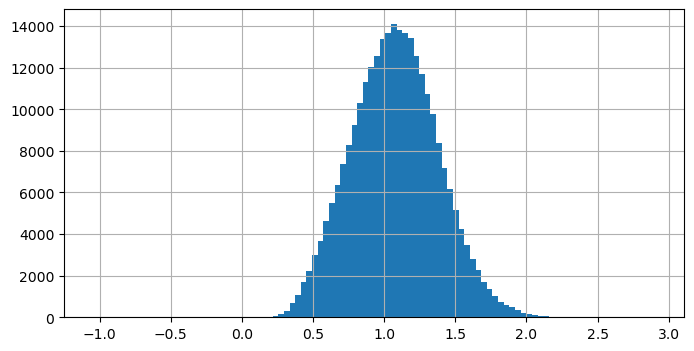

In [477]:
# 전체 분포 점검
display(beta_mkt.stack().describe())
display(beta_t.stack().describe())

beta_mkt.stack().hist(bins=100, figsize=(8, 4))

#### 3-3. 최근 월 기준 상위/하위 종목 점검

이 셀은 가장 최근 리밸런싱 날짜를 기준으로 종목별 값을 직접 확인한다.

출력 순서:

- 최근 월 `beta_mkt` 하위 10개
- 최근 월 `beta_mkt` 상위 10개
- 최근 월 `beta_t` 하위 10개
- 최근 월 `beta_t` 상위 10개

해석 팁:

- `beta_mkt` 상위 종목은 시장 민감도가 높은 종목일 가능성이 크다.
- `beta_mkt` 하위 종목은 방어주, 저베타주, 또는 특이한 가격 흐름을 가진 종목일 수 있다.
- `beta_t` 하위 종목은 베타 추정이 상대적으로 덜 안정적인 종목이다.
- 종목명이 전혀 납득되지 않게 반복해서 튀면 데이터 또는 회귀 설정을 다시 의심해볼 수 있다.

In [478]:
# 최근 월 기준 상하위 종목 확인
last_dt = beta_mkt.dropna(how="all").index[-1]
print("last rebalance date:", last_dt)

display(beta_mkt.loc[last_dt].dropna().sort_values().head(10))
display(beta_mkt.loc[last_dt].dropna().sort_values().tail(10))
display(beta_t.loc[last_dt].dropna().sort_values().head(10))
display(beta_t.loc[last_dt].dropna().sort_values().tail(10))

last rebalance date: 2026-03-13 00:00:00


정상제이엘에스    0.224820
한국기업평가     0.267801
메가스터디      0.314599
진양홀딩스      0.331865
아이마켓코리아    0.335618
창해에탄올      0.336783
이크레더블      0.338974
효성ITX      0.347892
KPX케미칼     0.355654
스카이라이프     0.375825
Name: 2026-03-13 00:00:00, dtype: float64

에이팩트        1.743292
오킨스전자       1.755014
와이씨         1.756326
덕산하이메탈      1.773812
삼화전기        1.807853
미래반도체       1.836659
코세스         1.846595
퀄리타스반도체     1.846634
에이디테크놀로지    1.860002
레이저쎌        1.930913
Name: 2026-03-13 00:00:00, dtype: float64

파라택시스이더리움    6.957119
동성화인텍        6.958064
노을           6.962239
율촌화학         6.962393
대성산업         6.970378
엔비티          6.970664
엔켐           6.976000
에코앤드림        6.991128
디어유          7.017984
리파인          7.025895
Name: 2026-03-13 00:00:00, dtype: float64

엘오티베큠       20.208282
인선이엔티       20.246909
SFA반도체      20.280785
SK하이닉스      20.317812
디와이         20.775702
동화약품        21.057662
아비코전자       21.268948
텔레칩스        21.689202
티이엠씨씨엔에스    22.805571
삼성전자        30.543037
Name: 2026-03-13 00:00:00, dtype: float64

#### 3-4. 필터 단계별 종목 수 비교

이 표는 각 필터 단계에서 종목 수가 어떻게 줄어드는지 보여준다.

열 설명:

- `basic_count`: 가격, 거래일수, 거래대금, 시가총액, 상장기간 조건까지 통과한 종목 수
- `beta_count_before_t`: 위 종목들 중 실제로 FF4 회귀가 계산된 종목 수
- `beta_t_count_before_t`: `t-stat`이 계산된 종목 수
- `final_count`: `t-stat` 필터까지 통과한 최종 종목 수
- `dropped_by_t_filter`: `t-stat` 필터 때문에 최종적으로 제외된 종목 수

해석 팁:

- `basic_count`와 `beta_count_before_t` 차이가 크면 회귀 창에서 결측이 많은 종목이 있다는 뜻일 수 있다.
- `beta_count_before_t`와 `final_count` 차이가 크면 `t-stat` 필터가 강하게 작동하고 있다는 뜻이다.
- `dropped_by_t_filter`가 계속 0이면 `t-stat` 필터가 사실상 의미가 없거나, 이미 매우 안정적인 종목들만 남아 있다는 뜻일 수 있다.
- 마지막 출력인 `beta_t_raw.abs().rank(axis=1, pct=True)`는 각 월에서 종목별 `|t-stat|` 백분위 순위를 보여준다.

In [479]:
# 필터 단계별 종목 수 확인
filter_counts = pd.DataFrame({
    "basic_count": basic_filter.sum(axis=1),
    "beta_count_before_t": beta_mkt_raw.notna().sum(axis=1),
    "beta_t_count_before_t": beta_t_raw.notna().sum(axis=1),
    "final_count": final_filter.sum(axis=1),
})
filter_counts["dropped_by_t_filter"] = filter_counts["beta_count_before_t"] - filter_counts["final_count"]

display(filter_counts.describe())
display(filter_counts.tail(12))
display(beta_t_raw.abs().rank(axis=1, pct=True).tail(3))

,basic_count,beta_count_before_t,beta_t_count_before_t,final_count,dropped_by_t_filter
count,291.000000,291.000000,291.000000,291.000000,291.000000
mean,1176.213058,1175.786942,1175.786942,941.013746,234.773196
std,319.825797,319.787617,319.787617,255.833162,63.955292
min,564.000000,564.000000,564.000000,452.000000,112.000000
25%,969.000000,968.000000,968.000000,774.500000,193.500000
50%,1154.000000,1154.000000,1154.000000,924.000000,230.000000
75%,1436.500000,1436.500000,1436.500000,1149.500000,287.000000
max,1683.000000,1683.000000,1683.000000,1347.000000,336.000000


,basic_count,beta_count_before_t,beta_t_count_before_t,final_count,dropped_by_t_filter
Date,,,,,
2025-04-30,1636,1635,1635,1308,327
2025-05-30,1635,1634,1634,1308,326
2025-06-30,1636,1635,1635,1308,327
2025-07-31,1640,1640,1640,1312,328
2025-08-29,1643,1643,1643,1315,328
2025-09-30,1655,1655,1655,1324,331
2025-10-31,1638,1638,1638,1311,327
2025-11-28,1630,1630,1630,1304,326
2025-12-30,1658,1658,1658,1327,331


,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,HD현대중공업,기아,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-30,1.0,0.999406,0.774807,0.052288,0.150921,0.017825,0.989305,0.707665,0.204397,0.834225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-27,1.0,0.998797,0.654633,0.070397,0.121540,0.007220,0.984958,0.663057,0.161252,0.788809,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-13,1.0,0.996381,0.771411,0.189385,0.022316,0.042823,0.956574,0.597708,0.109771,0.870326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 시장 베타

$\tilde{\beta}_{MKT} = \lambda \hat{\beta}_{MKT} + (1-\lambda)\times 1$

시장 베타는 장기 평균이 1이라서
1쪽으로 shrink합니다.


#### 스타일 베타
$\tilde{\beta}_{k} = \lambda \hat{\beta}_{k} + (1-\lambda)\times0$

스타일 베타는 장기 평균이 0이라서
0쪽으로 shrink합니다.

In [480]:
# shrink beta 생성
shr_beta_mkt = 0.6 * beta_mkt + 0.4 * 1.0
shr_beta_smb = 0.6 * beta_smb
shr_beta_hml = 0.6 * beta_hml
shr_beta_mom = 0.6 * beta_mom

### 4. EGARCH-t (국면 분류용)

In [481]:
# 라이브러리 import
from arch import arch_model

In [482]:
# EGARCH 추정용 시장 수익률
mkt_series = factor_ret["KOSPI200"].dropna()

In [483]:
# EGARCH 추정한 변동성 데이터프레임 생성
egarch_vol = pd.Series(index=rebalance_dates, dtype=float)

In [484]:
# 월말마다 최근 3년(756거래일) EGARCH-t 재추정
for dt in rebalance_dates:
    if dt not in mkt_series.index:
        continue

    end_idx = mkt_series.index.get_loc(dt)
    start_idx = end_idx - 755

    if start_idx < 0:
        continue

    window = mkt_series.iloc[start_idx:end_idx+1].dropna()

    if len(window) < 500:
        continue

    am = arch_model(
        window * 100,
        mean="Zero",
        vol="EGARCH",
        p=1,
        o=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")
    fcast = res.forecast(horizon=22, method="simulation", simulations=1000, reindex=False)

    next_month_var = fcast.variance.iloc[-1].sum()
    egarch_vol.loc[dt] = np.sqrt(next_month_var)

/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_76719/1942853872.py:27: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_76719/1942853872.py:27: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_76719/1942853872.py:27: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_76719/1942853872.py:27: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


In [485]:
# rolling quantile로 국면 분류
vol_q70 = egarch_vol.rolling(36, min_periods=24).quantile(0.7)
vol_q10 = egarch_vol.rolling(36, min_periods=24).quantile(0.1)
high_vol_regime = egarch_vol >= vol_q70
very_low_vol_regime = egarch_vol <= vol_q10

#### 4-1. EGARCH 예측 검증

EGARCH-t가 예측한 다음 달 변동성이 실제 다음 달 실현변동성과 얼마나 잘 맞는지 확인한다.

확인 내용:

- `pred_vol`: EGARCH-t가 예측한 다음 달 변동성
- `realized_vol`: 실제 다음 달 시장수익률로 계산한 실현변동성
- `pred_high_vol`: EGARCH 기준 고변동 국면 여부
- `realized_high_vol`: 실현변동성 기준 고변동 국면 여부

해석 팁:

- `corr(pred, realized)`가 높을수록 예측 방향성이 좋다.
- `MAE`, `RMSE`가 낮을수록 예측 오차가 작다.
- `regime_hit_rate`가 높을수록 고변동/저변동 구분이 실제와 잘 맞는다.
- `avg_realized_vol_when_pred_high > avg_realized_vol_when_pred_low`이면 국면 분류가 최소한 방향성은 있다는 뜻이다.

corr(pred, realized)                   2.958990e-03
MAE                                    6.817056e+59
RMSE                                   1.134584e+61
regime_hit_rate                        7.328520e-01
avg_realized_vol_when_pred_high        6.918395e+00
avg_realized_vol_when_pred_low         4.821481e+00
avg_next_ret_when_pred_high_vol        1.253856e-02
avg_next_ret_when_pred_low_vol         9.733087e-03
avg_next_ret_when_realized_high_vol    1.109026e-03
avg_next_ret_when_realized_low_vol     1.456224e-02
dtype: float64

,pred_vol,realized_vol,pred_high_vol,realized_high_vol,next_month_market_ret
Date,,,,,
2025-03-31,6.201899,9.891479,True,True,0.019073
2025-04-30,5.250067,4.434995,False,False,0.061640
2025-05-30,5.092087,6.007588,False,True,0.152884
2025-06-30,5.330379,4.438378,False,False,0.057887
2025-07-31,5.260303,5.525403,False,False,-0.019334
2025-08-29,5.546045,5.843427,False,True,0.102088
2025-09-30,5.640534,7.900308,False,True,0.222412
2025-10-31,5.749489,10.624607,True,True,-0.043937
2025-11-28,6.998442,6.676732,True,True,0.093827


<Axes: title={'center': 'EGARCH Predicted vs Realized Next-Month Volatility'}, xlabel='Date'>

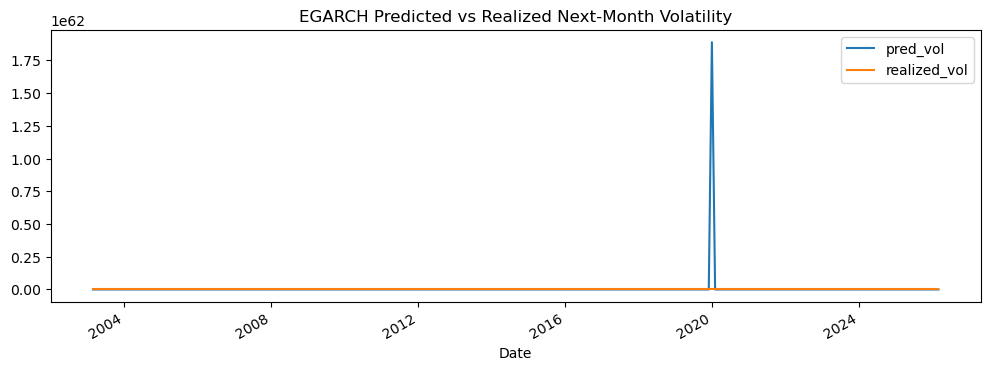

In [486]:
# EGARCH 예측 검증
eval_dates = egarch_vol.dropna().index.intersection(rebalance_dates[:-1])
next_dt_map = pd.Series(rebalance_dates[1:], index=rebalance_dates[:-1])

realized_vol = pd.Series(index=eval_dates, dtype=float)
for dt in eval_dates:
    next_dt = next_dt_map.loc[dt]
    next_window = mkt_series.loc[(mkt_series.index > dt) & (mkt_series.index <= next_dt)] * 100
    if len(next_window) == 0:
        continue
    realized_vol.loc[dt] = np.sqrt((next_window ** 2).sum())

egarch_eval = pd.DataFrame({
    "pred_vol": egarch_vol.loc[eval_dates],
    "realized_vol": realized_vol,
}).dropna()

next_month_market_ret = pd.Series(index=eval_dates, dtype=float)
for dt in eval_dates:
    next_dt = next_dt_map.loc[dt]
    next_ret_window = mkt_series.loc[(mkt_series.index > dt) & (mkt_series.index <= next_dt)]
    if len(next_ret_window) == 0:
        continue
    next_month_market_ret.loc[dt] = (1 + next_ret_window).prod() - 1
egarch_eval["next_month_market_ret"] = next_month_market_ret

realized_q70 = egarch_eval["realized_vol"].rolling(36, min_periods=24).quantile(0.7)
egarch_eval["pred_high_vol"] = high_vol_regime.loc[egarch_eval.index]
egarch_eval["realized_high_vol"] = egarch_eval["realized_vol"] >= realized_q70
egarch_eval["abs_error"] = (egarch_eval["pred_vol"] - egarch_eval["realized_vol"]).abs()
egarch_eval["sq_error"] = (egarch_eval["pred_vol"] - egarch_eval["realized_vol"]) ** 2

valid_regime = egarch_eval[["pred_high_vol", "realized_high_vol"]].dropna()
egarch_summary = pd.Series({
    "corr(pred, realized)": egarch_eval["pred_vol"].corr(egarch_eval["realized_vol"]),
    "MAE": egarch_eval["abs_error"].mean(),
    "RMSE": np.sqrt(egarch_eval["sq_error"].mean()),
    "regime_hit_rate": (valid_regime["pred_high_vol"] == valid_regime["realized_high_vol"]).mean(),
    "avg_realized_vol_when_pred_high": egarch_eval.loc[egarch_eval["pred_high_vol"], "realized_vol"].mean(),
    "avg_realized_vol_when_pred_low": egarch_eval.loc[~egarch_eval["pred_high_vol"], "realized_vol"].mean(),
    "avg_next_ret_when_pred_high_vol": egarch_eval.loc[egarch_eval["pred_high_vol"], "next_month_market_ret"].mean(),
    "avg_next_ret_when_pred_low_vol": egarch_eval.loc[~egarch_eval["pred_high_vol"], "next_month_market_ret"].mean(),
    "avg_next_ret_when_realized_high_vol": egarch_eval.loc[egarch_eval["realized_high_vol"], "next_month_market_ret"].mean(),
    "avg_next_ret_when_realized_low_vol": egarch_eval.loc[~egarch_eval["realized_high_vol"], "next_month_market_ret"].mean(),
})

display(egarch_summary)
display(egarch_eval[["pred_vol", "realized_vol", "pred_high_vol", "realized_high_vol", "next_month_market_ret"]].tail(12))
egarch_eval[["pred_vol", "realized_vol"]].plot(figsize=(12, 4), title="EGARCH Predicted vs Realized Next-Month Volatility")

In [487]:
# EGARCH 검증 결과 CSV 저장
egarch_eval.to_csv("egarch_eval.csv", encoding="utf-8-sig")
egarch_summary.to_csv("egarch_summary.csv", encoding="utf-8-sig")

print("saved:")
print("- egarch_eval.csv")
print("- egarch_summary.csv")

saved:
- egarch_eval.csv
- egarch_summary.csv


In [488]:
# EGARCH 검증 결과 해석
corr_val = egarch_summary.get("corr(pred, realized)")
hit_val = egarch_summary.get("regime_hit_rate")
pred_high_ret = egarch_summary.get("avg_next_ret_when_pred_high_vol")
pred_low_ret = egarch_summary.get("avg_next_ret_when_pred_low_vol")
real_high_ret = egarch_summary.get("avg_next_ret_when_realized_high_vol")
real_low_ret = egarch_summary.get("avg_next_ret_when_realized_low_vol")

if pd.notna(corr_val):
    if corr_val >= 0.6:
        print(f"예측 방향성은 강한 편입니다. corr = {corr_val:.3f}")
    elif corr_val >= 0.3:
        print(f"예측 방향성은 보통입니다. corr = {corr_val:.3f}")
    else:
        print(f"예측 방향성은 약한 편입니다. corr = {corr_val:.3f}")

if pd.notna(hit_val):
    print(f"고변동/저변동 국면 적중률은 {hit_val:.3%} 입니다.")

if pd.notna(pred_high_ret) and pd.notna(pred_low_ret):
    if pred_high_ret < pred_low_ret:
        print(f"EGARCH가 고변동으로 예측한 달의 다음 달 평균 수익률({pred_high_ret:.3%})은 저변동 예측 달({pred_low_ret:.3%})보다 낮았습니다.")
    elif pred_high_ret > pred_low_ret:
        print(f"EGARCH가 고변동으로 예측한 달의 다음 달 평균 수익률({pred_high_ret:.3%})은 저변동 예측 달({pred_low_ret:.3%})보다 높았습니다.")
    else:
        print("EGARCH 예측 기준으로는 고변동/저변동 달의 다음 달 평균 수익률 차이가 거의 없습니다.")

if pd.notna(real_high_ret) and pd.notna(real_low_ret):
    if real_high_ret < real_low_ret:
        print(f"실현변동성 기준으로도 고변동 달의 다음 달 평균 수익률({real_high_ret:.3%})은 저변동 달({real_low_ret:.3%})보다 낮았습니다.")
    elif real_high_ret > real_low_ret:
        print(f"실현변동성 기준으로는 고변동 달의 다음 달 평균 수익률({real_high_ret:.3%})이 저변동 달({real_low_ret:.3%})보다 높았습니다.")
    else:
        print("실현변동성 기준으로도 고변동/저변동 달의 다음 달 평균 수익률 차이가 거의 없습니다.")

예측 방향성은 약한 편입니다. corr = 0.003
고변동/저변동 국면 적중률은 73.285% 입니다.
EGARCH가 고변동으로 예측한 달의 다음 달 평균 수익률(1.254%)은 저변동 예측 달(0.973%)보다 높았습니다.
실현변동성 기준으로도 고변동 달의 다음 달 평균 수익률(0.111%)은 저변동 달(1.456%)보다 낮았습니다.


#### 4-2. EGARCH 검증 해석 요약

현재 결과 해석:

- `corr(pred, realized)`가 매우 낮으면 EGARCH가 다음 달 변동성의 **수준 자체**는 잘 맞추지 못한다는 뜻이다.
- `regime_hit_rate`가 어느 정도 높더라도, 그것만으로 투자에 유용하다고 보긴 어렵다. 실제로는 고변동으로 예측된 달과 저변동으로 예측된 달의 **다음 달 수익률 차이**가 더 중요하다.
- 만약 `avg_next_ret_when_pred_high_vol > avg_next_ret_when_pred_low_vol`가 나오면, EGARCH가 고변동으로 예측한 달이 오히려 다음 달 수익률이 더 좋았다는 뜻이므로 `고변동이면 방어`라는 국면전환 논리와 충돌한다.
- 반대로 실현변동성 기준에서는 `avg_next_ret_when_realized_high_vol < avg_next_ret_when_realized_low_vol`가 나오면, 실제 시장에서는 고변동 다음 달 수익률이 더 약한 경향이 있다는 뜻이다.

즉, 현재 결과가 `예측 기준에서는 고변동 다음 달 수익률이 더 높고`, `실현 기준에서는 고변동 다음 달 수익률이 더 낮다`면,
EGARCH가 투자에 필요한 방향으로 고변동 국면을 선별하지 못하고 있을 가능성이 높다.

이 경우에는 EGARCH 국면전환 전략을 메인 전략으로 쓰기보다,
`Defensive Only` 같은 고정 전략을 기준 전략으로 두고 EGARCH는 보조 실험으로만 해석하는 것이 더 타당하다.

#### 4-3. EGARCH-X with Volume (실험)

Choi et al. (2012)의 아이디어를 반영해 거래량 항을 추가한 EGARCH-X를 실험한다.

여기서는 시장 전체 거래대금을 합산한 뒤 로그 변환하여 거래량 대리변수로 사용하고,
QMLE 방식으로 EGARCH-X를 적합한다.

주의:

- `arch` 패키지 기본 함수로는 분산식 외생변수 추가가 불편하므로, 아래에서는 간단한 custom likelihood를 사용한다.
- 이 블록은 연구용 실험이다. 기본 EGARCH보다 계산이 더 느리다.

In [ ]:
from scipy.optimize import minimize
from scipy.special import gammaln

market_trading_value = trading_value.sum(axis=1, min_count=1).reindex(common_index)
log_market_volume = np.log1p(market_trading_value)
volume_proxy = ((log_market_volume - log_market_volume.rolling(252, min_periods=126).mean()) /
                log_market_volume.rolling(252, min_periods=126).std())
volume_proxy = volume_proxy.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def fit_egarchx_volume_qmle(ret_window, vol_window):
    y = pd.Series(ret_window).dropna()
    v = pd.Series(vol_window).reindex(y.index).fillna(0.0)
    if len(y) < 500:
        return None

    y_arr = (y.to_numpy(dtype=float) * 100.0)
    v_arr = v.to_numpy(dtype=float)
    v_arr = (v_arr - np.nanmean(v_arr)) / (np.nanstd(v_arr) + 1e-8)
    c = np.sqrt(2.0 / np.pi)

    def unpack(params):
        omega = params[0]
        alpha = params[1]
        gamma = params[2]
        beta = 1.0 / (1.0 + np.exp(-params[3]))
        theta = params[4]
        nu = 2.0 + np.exp(params[5])
        return omega, alpha, gamma, beta, theta, nu

    def neg_ll(params):
        omega, alpha, gamma, beta, theta, nu = unpack(params)
        logh = np.empty_like(y_arr)
        logh[0] = np.log(np.var(y_arr) + 1e-6)

        for t in range(1, len(y_arr)):
            z_prev = y_arr[t - 1] / np.sqrt(np.exp(logh[t - 1]))
            logh[t] = (
                omega
                + beta * logh[t - 1]
                + alpha * (np.abs(z_prev) - c)
                + gamma * z_prev
                + theta * v_arr[t - 1]
            )

        h = np.exp(np.clip(logh, -20, 20))
        ll = (
            gammaln((nu + 1.0) / 2.0)
            - gammaln(nu / 2.0)
            - 0.5 * np.log((nu - 2.0) * np.pi)
            - 0.5 * np.log(h)
            - ((nu + 1.0) / 2.0) * np.log(1.0 + (y_arr ** 2) / ((nu - 2.0) * h))
        )
        if not np.isfinite(ll).all():
            return 1e12
        return -ll.sum()

    x0 = np.array([0.0, 0.10, -0.05, 2.0, 0.05, np.log(8.0)])
    res = minimize(neg_ll, x0=x0, method='L-BFGS-B')
    if (not res.success) or (not np.isfinite(res.fun)):
        return None

    omega, alpha, gamma, beta, theta, nu = unpack(res.x)
    logh = np.empty_like(y_arr)
    logh[0] = np.log(np.var(y_arr) + 1e-6)
    for t in range(1, len(y_arr)):
        z_prev = y_arr[t - 1] / np.sqrt(np.exp(logh[t - 1]))
        logh[t] = (
            omega
            + beta * logh[t - 1]
            + alpha * (np.abs(z_prev) - c)
            + gamma * z_prev
            + theta * v_arr[t - 1]
        )

    sigma_t = np.sqrt(np.exp(np.clip(logh[-1], -20, 20)))
    return {
        'omega': omega,
        'alpha': alpha,
        'gamma': gamma,
        'beta': beta,
        'theta': theta,
        'nu': nu,
        'sigma_t': sigma_t,
        'success': res.success,
        'nobs': len(y_arr),
    }


In [ ]:
egarchx_vol = pd.Series(index=rebalance_dates, dtype=float)
egarchx_theta = pd.Series(index=rebalance_dates, dtype=float)

for dt in rebalance_dates:
    if dt not in mkt_series.index or dt not in volume_proxy.index:
        continue

    end_idx = mkt_series.index.get_loc(dt)
    start_idx = end_idx - 755
    if start_idx < 0:
        continue

    window_index = mkt_series.index[start_idx:end_idx+1]
    result = fit_egarchx_volume_qmle(mkt_series.loc[window_index], volume_proxy.loc[window_index])
    if result is None:
        continue

    egarchx_vol.loc[dt] = result['sigma_t']
    egarchx_theta.loc[dt] = result['theta']

egarchx_q70 = egarchx_vol.rolling(36, min_periods=24).quantile(0.7)
egarchx_high_vol_regime = egarchx_vol >= egarchx_q70

display(pd.Series({
    'egarchx_nonnull': egarchx_vol.notna().sum(),
    'mean_theta': egarchx_theta.mean(),
    'median_theta': egarchx_theta.median(),
} ))
display(egarchx_vol.dropna().tail())

#### 4-4. Markov Switching (실험)

2-state Markov Switching model로 시장수익률의 고변동 상태 확률을 추정한다.

여기서는 `statsmodels`의 `MarkovRegression`을 이용해 rolling window로 적합하고,
분산이 더 큰 regime의 smoothed probability를 고변동 확률로 사용한다.

주의:

- 커널에 `statsmodels`가 설치되어 있어야 한다.
- 계산이 꽤 느릴 수 있다.

In [ ]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

ms_high_vol_prob = pd.Series(index=rebalance_dates, dtype=float)

for dt in rebalance_dates:
    if dt not in mkt_series.index:
        continue

    end_idx = mkt_series.index.get_loc(dt)
    start_idx = end_idx - 755
    if start_idx < 0:
        continue

    window = (mkt_series.iloc[start_idx:end_idx+1] * 100).dropna()
    if len(window) < 500:
        continue

    try:
        model = MarkovRegression(window, k_regimes=2, trend='c', switching_variance=True)
        res = model.fit(disp=False)
        regime_vars = []
        for k in range(2):
            regime_vars.append(res.params.get(f'sigma2[{k}]', np.nan))
        high_regime = int(np.nanargmax(regime_vars))
        ms_high_vol_prob.loc[dt] = res.smoothed_marginal_probabilities[high_regime].iloc[-1]
    except Exception:
        continue

ms_high_vol_regime = ms_high_vol_prob >= 0.5
display(ms_high_vol_prob.dropna().describe())
display(ms_high_vol_prob.dropna().tail())

In [ ]:
# 세 가지 국면 신호 비교
regime_compare = pd.DataFrame({
    'egarch_vol': egarch_vol,
    'egarch_high': high_vol_regime,
    'egarchx_vol': egarchx_vol,
    'egarchx_high': egarchx_high_vol_regime,
    'ms_high_prob': ms_high_vol_prob,
    'ms_high': ms_high_vol_regime,
}).loc[rebalance_dates]

display(regime_compare.tail(12))
display(pd.DataFrame({
    'EGARCH high count': [high_vol_regime.sum()],
    'EGARCH-X high count': [egarchx_high_vol_regime.sum()],
    'MS high count': [ms_high_vol_regime.sum()],
}))

#### 4-5. EGARCH / EGARCH-X / Markov Switching 검증 비교

세 모델을 동일한 기준으로 비교한다.

비교 항목:

- `corr(pred, realized)`: 예측 변동성과 실현변동성 상관
- `regime_hit_rate`: 고변동/저변동 국면 적중률
- `avg_realized_vol_when_pred_high`: 고변동으로 예측한 달의 실제 실현변동성 평균
- `avg_next_ret_when_pred_high_vol`: 고변동으로 예측한 달의 다음 달 평균 수익률
- `avg_next_ret_when_pred_low_vol`: 저변동으로 예측한 달의 다음 달 평균 수익률

핵심은 단순 적중률보다도, 고변동으로 예측한 달이 실제로 더 위험했고 다음 달 수익률이 더 약했는지 확인하는 것이다.

In [ ]:
def evaluate_regime_model(pred_vol_series, pred_high_series, model_name, realized_vol, next_month_market_ret):
    eval_idx = pred_vol_series.dropna().index.intersection(realized_vol.dropna().index)
    df = pd.DataFrame({
        'pred_vol': pred_vol_series.loc[eval_idx],
        'realized_vol': realized_vol.loc[eval_idx],
        'next_month_market_ret': next_month_market_ret.loc[eval_idx],
        'pred_high_vol': pred_high_series.loc[eval_idx],
    }).dropna()

    realized_q70_local = df['realized_vol'].rolling(36, min_periods=24).quantile(0.7)
    df['realized_high_vol'] = df['realized_vol'] >= realized_q70_local
    valid = df[['pred_high_vol', 'realized_high_vol']].dropna()

    summary = pd.Series({
        'corr(pred, realized)': df['pred_vol'].corr(df['realized_vol']),
        'regime_hit_rate': (valid['pred_high_vol'] == valid['realized_high_vol']).mean(),
        'avg_realized_vol_when_pred_high': df.loc[df['pred_high_vol'], 'realized_vol'].mean(),
        'avg_realized_vol_when_pred_low': df.loc[~df['pred_high_vol'], 'realized_vol'].mean(),
        'avg_next_ret_when_pred_high_vol': df.loc[df['pred_high_vol'], 'next_month_market_ret'].mean(),
        'avg_next_ret_when_pred_low_vol': df.loc[~df['pred_high_vol'], 'next_month_market_ret'].mean(),
    }, name=model_name)
    return summary, df

egarch_model_summary, egarch_model_eval = evaluate_regime_model(
    egarch_vol, high_vol_regime, 'EGARCH', realized_vol, next_month_market_ret
)
egarchx_model_summary, egarchx_model_eval = evaluate_regime_model(
    egarchx_vol, egarchx_high_vol_regime, 'EGARCH-X', realized_vol, next_month_market_ret
)
ms_model_summary, ms_model_eval = evaluate_regime_model(
    ms_high_vol_prob, ms_high_vol_regime, 'Markov Switching', realized_vol, next_month_market_ret
)

model_compare = pd.concat([
    egarch_model_summary,
    egarchx_model_summary,
    ms_model_summary,
], axis=1)

display(model_compare)
display(pd.DataFrame({
    'EGARCH pred_high': egarch_model_eval['pred_high_vol'].tail(12),
    'EGARCH-X pred_high': egarchx_model_eval['pred_high_vol'].tail(12),
    'MS pred_high': ms_model_eval['pred_high_vol'].tail(12),
    'Realized high': egarch_model_eval['realized_high_vol'].tail(12),
    'Next month ret': egarch_model_eval['next_month_market_ret'].tail(12),
}))

In [ ]:
# 비교 결과 CSV 저장
model_compare.to_csv('regime_model_compare.csv', encoding='utf-8-sig')
print('saved: regime_model_compare.csv')

#### 4-6. EGARCH-X + Markov Switching 혼합 신호

세 가지 혼합 규칙을 실험한다.

- `AND`: 둘 다 고변동일 때만 고변동으로 판단
- `OR`: 둘 중 하나라도 고변동이면 고변동으로 판단
- `Weighted`: EGARCH-X의 rolling percentile score와 MS high probability를 50:50으로 결합

혼합 신호도 동일한 검증 기준으로 비교해서, 단순 결합이 실제로 도움이 되는지 본다.

In [ ]:
def rolling_percentile_score(series, window=36, min_periods=24):
    out = pd.Series(index=series.index, dtype=float)
    for i in range(len(series)):
        start = max(0, i - window + 1)
        hist = series.iloc[start:i+1].dropna()
        if len(hist) < min_periods:
            continue
        out.iloc[i] = hist.rank(pct=True).iloc[-1]
    return out

and_high_vol_regime = egarchx_high_vol_regime & ms_high_vol_regime
or_high_vol_regime = egarchx_high_vol_regime | ms_high_vol_regime
egarchx_score = rolling_percentile_score(egarchx_vol)
combined_score = 0.5 * egarchx_score + 0.5 * ms_high_vol_prob.reindex(egarchx_score.index)
combined_score_q70 = combined_score.rolling(36, min_periods=24).quantile(0.7)
weighted_high_vol_regime = combined_score >= combined_score_q70

and_summary, and_eval = evaluate_regime_model(
    egarchx_vol, and_high_vol_regime, 'EGARCH-X AND MS', realized_vol, next_month_market_ret
)
or_summary, or_eval = evaluate_regime_model(
    egarchx_vol, or_high_vol_regime, 'EGARCH-X OR MS', realized_vol, next_month_market_ret
)
weighted_summary, weighted_eval = evaluate_regime_model(
    combined_score, weighted_high_vol_regime, 'Weighted Combo', realized_vol, next_month_market_ret
)

hybrid_compare = pd.concat([and_summary, or_summary, weighted_summary], axis=1)
display(hybrid_compare)
display(pd.DataFrame({
    'AND high': and_high_vol_regime.tail(12),
    'OR high': or_high_vol_regime.tail(12),
    'Weighted high': weighted_high_vol_regime.tail(12),
    'Realized high': egarch_model_eval['realized_high_vol'].tail(12),
    'Next month ret': egarch_model_eval['next_month_market_ret'].tail(12),
}))

In [ ]:
hybrid_compare.to_csv('hybrid_regime_compare.csv', encoding='utf-8-sig')
print('saved: hybrid_regime_compare.csv')

rank 평균 방식

공격 포트폴리오

- shr_beta_mkt 높을수록 좋음

- shr_beta_smb 높을수록 좋음

- shr_beta_mom 높을수록 좋음

베타 추정 신뢰도는 이미 `t-stat` 필터에서 반영했지만,
공격 포트폴리오의 변동성을 조금 누르기 위해 `beta_se`를 이전보다 더 반영한다.

In [489]:
# 공격 포트폴리오
agg_rank = (
    0.35 * shr_beta_mkt.rank(axis=1, pct=True)
    + 0.20 * shr_beta_smb.rank(axis=1, pct=True)
    + 0.20 * shr_beta_mom.rank(axis=1, pct=True)
    + 0.25 * (-beta_se).rank(axis=1, pct=True)
)

방어 포트폴리오

- shr_beta_mkt 낮을수록 좋음

- shr_beta_smb 낮을수록 좋음

- shr_beta_hml 높을수록 좋음

베타 추정 신뢰도는 이미 `t-stat` 필터에서 반영했지만,
종목 품질 통제를 위해 `beta_se`를 낮은 가중치로만 반영한다.

In [490]:
def_rank = (
    0.3 * (-shr_beta_mkt).rank(axis=1, pct=True)
    + 0.3 * (-shr_beta_smb).rank(axis=1, pct=True)
    + 0.3 * shr_beta_hml.rank(axis=1, pct=True)
    + 0.1 * (-beta_se).rank(axis=1, pct=True)
)

In [491]:
# 최종 필터 반영
agg_rank = agg_rank.where(final_filter)
def_rank = def_rank.where(final_filter)

In [492]:
# 상위 20% 동일 가중
agg_selected = agg_rank.rank(axis=1, pct=True) >= 0.80
def_selected = def_rank.rank(axis=1, pct=True) >= 0.80

#### 모델 출력 저장

방어(가치) 모델과 공격 모델에서 계산된 점수와 선택 결과를 CSV로 저장한다.

주요 파일:

- `def_rank.csv`: 방어(가치) 모델 점수
- `def_selected.csv`: 방어(가치) 모델 상위 20% 선택 여부
- `agg_rank.csv`: 공격 모델 점수
- `agg_selected.csv`: 공격 모델 상위 20% 선택 여부

In [493]:
# 모델 출력 CSV 저장
def_rank.to_csv("def_rank.csv", encoding="utf-8-sig")
def_selected.astype(int).to_csv("def_selected.csv", encoding="utf-8-sig")
agg_rank.to_csv("agg_rank.csv", encoding="utf-8-sig")
agg_selected.astype(int).to_csv("agg_selected.csv", encoding="utf-8-sig")

print("saved:")
print("- def_rank.csv")
print("- def_selected.csv")
print("- agg_rank.csv")
print("- agg_selected.csv")

saved:
- def_rank.csv
- def_selected.csv
- agg_rank.csv
- agg_selected.csv


In [494]:
# 기존 국면 스위칭: 고변동이면 방어, 아니면 공격
portfolio_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)
conservative_portfolio_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)

for dt in rebalance_dates:
    if dt not in high_vol_regime.index:
        continue

    if high_vol_regime.loc[dt]:
        portfolio_mask.loc[dt] = def_selected.loc[dt]
    else:
        portfolio_mask.loc[dt] = agg_selected.loc[dt]

    # 보수형 스위칭: 기본은 방어, 아주 강한 저변동 구간에서만 공격
    if dt in very_low_vol_regime.index and bool(very_low_vol_regime.loc[dt]):
        conservative_portfolio_mask.loc[dt] = agg_selected.loc[dt]
    else:
        conservative_portfolio_mask.loc[dt] = def_selected.loc[dt]

In [495]:
# 동일 가중 weight
weights = portfolio_mask.astype(float)
weights = weights.div(weights.sum(axis=1), axis=0)

### 5. 포트폴리오 수익률 계산

In [496]:
# 다음 리밸런싱 날짜까지 보유하되, 마지막 부분월은 제외
backtest_rebalance_dates = rebalance_dates[:-1]
next_rebalance_dates = rebalance_dates[1:]

In [497]:
# 수익률 저장할 시리즈 생성
portfolio_ret = pd.Series(index=backtest_rebalance_dates, dtype=float)
portfolio_daily_ret = pd.Series(index=ret.index, dtype=float)

In [498]:
# 월 리밸런싱

for i, dt in enumerate(backtest_rebalance_dates):
    start_dt = dt
    end_dt = next_rebalance_dates[i]

    if dt not in weights.index:
        continue

    w = weights.loc[dt].dropna()
    w = w[w > 0]

    if len(w) == 0:
        continue

    holding_period = ret.loc[(ret.index > start_dt) & (ret.index <= end_dt), w.index]

    daily_port_ret = holding_period.mul(w, axis=1).sum(axis=1)
    portfolio_daily_ret.loc[daily_port_ret.index] = daily_port_ret

    portfolio_ret.loc[dt] = (1 + daily_port_ret).prod() - 1

In [499]:
portfolio_ret = portfolio_ret.dropna()
portfolio_daily_ret = portfolio_daily_ret.dropna()

In [500]:
portfolio_ret.head()

Date
2002-01-31    0.062334
2002-02-28    0.110660
2002-03-29   -0.200211
2002-04-30   -0.037907
2002-05-31   -0.146493
dtype: float64

In [501]:
portfolio_daily_ret.head()

Date
2002-02-01   -0.022803
2002-02-04   -0.028216
2002-02-05    0.014669
2002-02-06    0.000877
2002-02-07   -0.031509
dtype: float64

In [502]:
cumret = (1 + portfolio_ret).cumprod()
cumret_daily = (1 + portfolio_daily_ret).cumprod()

In [503]:
cumret.tail()

Date
2025-10-31    2.851907
2025-11-28    2.871773
2025-12-30    3.040322
2026-01-30    3.396404
2026-02-27    3.190867
dtype: float64

### 6. 벤치마크와 비교

In [504]:
# 벤치마크 월별 수익률
benchmark_monthly = factor["KOSPI200"].loc[rebalance_dates].pct_change().loc[backtest_rebalance_dates].dropna()

In [505]:
# 포트폴리오와 벤치마크 비교

result = pd.concat(
    [
        portfolio_ret.rename("portfolio"),
        benchmark_monthly.rename("benchmark")
    ],
    axis=1
).dropna()

In [506]:
result.head()

,portfolio,benchmark
Date,,
2002-02-28,0.110660,0.103560
2002-03-29,-0.200211,0.089846
2002-04-30,-0.037907,-0.048730
2002-05-31,-0.146493,-0.052543
2002-06-28,0.018696,-0.070536


### 7. 성과지표

In [507]:
def performance_stats(r):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    n_months = len(r)
    total_return = wealth.iloc[-1] - 1
    cagr = wealth.iloc[-1] ** (12 / n_months) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe = np.nan if ann_vol == 0 else (r.mean() * 12) / ann_vol
    hit_rate = (r > 0).mean()

    return pd.Series({
        "CAGR": cagr,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": drawdown.min(),
        "Hit Rate": hit_rate,
        "Total Return": total_return,
    })

perf_table = pd.concat(
    {
        "Portfolio": performance_stats(result["portfolio"]),
        "Benchmark": performance_stats(result["benchmark"]),
    },
    axis=1,
)

display(perf_table)
display((1 + result).cumprod().tail())

,Portfolio,Benchmark
CAGR,0.046726,0.100498
Annualized Vol,0.247118,0.208424
Sharpe,0.310736,0.563641
Max Drawdown,-0.542885,-0.469818
Hit Rate,0.560554,0.577855
Total Return,2.003637,9.036993


,portfolio,benchmark
Date,,
2025-10-31,2.684566,6.231423
2025-11-28,2.703266,5.957630
2025-12-30,2.861926,6.516615
2026-01-30,3.197114,8.263362
2026-02-27,3.003637,10.036993


### 8. 전략 진단

성과가 약할 때는 공격 포트폴리오 자체가 약한지, 방어 포트폴리오 자체가 약한지,
아니면 국면 스위칭이 잘못되고 있는지를 분해해서 봐야 한다.

아래 셀들은 다음을 확인한다.

- `Aggressive Only`: 공격 포트폴리오만 계속 들고 갔을 때 성과
- `Defensive Only`: 방어 포트폴리오만 계속 들고 갔을 때 성과
- `Switching`: 현재 구현한 EGARCH 국면 스위칭 전략 성과
- `Conservative Switching`: 기본은 방어, 변동성 하위 10% 수준의 극단적 저변동 구간에서만 공격하는 보수형 전략
- `EGARCH-X Switching`: 거래량 항을 포함한 EGARCH-X가 고변동이라고 판단할 때만 방어하는 전략
- `EGARCH-X Cash Filter`: 기본은 방어를 유지하되, EGARCH-X가 극단적 고변동이라고 판단할 때는 현금(무투자)으로 대기하는 전략
- `AND Cash Filter`: 기본은 방어를 유지하되, `EGARCH-X`와 `MS`가 동시에 위험 신호를 줄 때만 현금으로 대기하는 전략
- `EGARCH-X 3-State`: EGARCH-X가 매우 저변동이면 공격, 보통 구간이면 방어, 극단적 고변동이면 현금으로 가는 3상태 전략
- `MS Switching`: Markov Switching이 고변동이라고 판단할 때만 방어하는 전략
- `AND Switching`: `EGARCH-X`와 `Markov Switching`이 모두 고변동이라고 판단할 때만 방어하는 혼합 전략
- `Weighted Switching`: `EGARCH-X` score와 `MS probability`를 결합한 혼합 전략
- `Regime Counts`: 고변동/저변동 국면이 얼마나 자주 나오는지
- `active return`: 벤치마크 대비 초과수익률 분포

기준 차이도 중요하다.

기존 EGARCH/보수형 스위칭은 국면 모델을 `언제 공격으로 갈지`를 정하는 보조 신호로 사용했다.
즉 기본 상태는 방어이고, 아주 낮은 변동성에서만 공격을 허용하는 구조였다.

반면 EGARCH-X는 거래량 항이 추가되면서 `고변동을 더 잘 잡는 리스크 신호`에 가까워졌다.
이 경우에는 단순히 공격/방어를 스위칭하는 것보다,
`위험이 매우 높을 때는 아예 노출을 줄이거나 현금으로 대기`하는 규칙이 더 자연스러울 수 있다.

즉 발전시킨 모델에는 같은 포트폴리오 선택 규칙을 그대로 적용하기보다,
다음처럼 해석 체계를 바꾸는 실험이 필요하다.

- 기본 EGARCH: 공격/방어 스위칭 보조도구
- EGARCH-X: 극단 리스크 필터 또는 3상태 배분 도구
- EGARCH-X + MS: 동시 위험 확인용 현금필터
- MS: 상태 전환 확률 기반 보조 신호

이 결과를 보면 문제 원인이 종목선정인지, 국면판단인지 훨씬 쉽게 좁혀진다.

In [508]:
EGARCHX_LOW_Q = 0.10
EGARCHX_EXTREME_HIGH_Q = 0.90

def build_equal_weight_portfolio(selection_mask, rebalance_dates_used, ret):
    weights_local = selection_mask.astype(float)
    weights_local = weights_local.div(weights_local.sum(axis=1), axis=0)

    port_ret = pd.Series(index=rebalance_dates_used, dtype=float)
    port_daily_ret = pd.Series(index=ret.index, dtype=float)
    next_dates = list(rebalance_dates_used[1:]) + [rebalance_dates[-1]]

    for i, dt in enumerate(rebalance_dates_used):
        end_dt = next_dates[i]
        w = weights_local.loc[dt].dropna()
        w = w[w > 0]
        if len(w) == 0:
            zero_idx = ret.index[(ret.index > dt) & (ret.index <= end_dt)]
            port_daily_ret.loc[zero_idx] = 0.0
            port_ret.loc[dt] = 0.0
            continue

        holding_period = ret.loc[(ret.index > dt) & (ret.index <= end_dt), w.index]
        daily_port_ret = holding_period.mul(w, axis=1).sum(axis=1)
        port_daily_ret.loc[daily_port_ret.index] = daily_port_ret
        port_ret.loc[dt] = (1 + daily_port_ret).prod() - 1

    return port_ret.dropna(), port_daily_ret.dropna()

egarchx_low_q = egarchx_vol.rolling(36, min_periods=24).quantile(EGARCHX_LOW_Q)
egarchx_extreme_high_q = egarchx_vol.rolling(36, min_periods=24).quantile(EGARCHX_EXTREME_HIGH_Q)
egarchx_very_low_vol_regime = egarchx_vol <= egarchx_low_q
egarchx_extreme_high_vol_regime = egarchx_vol >= egarchx_extreme_high_q

agg_only_mask = agg_selected.loc[backtest_rebalance_dates]
def_only_mask = def_selected.loc[backtest_rebalance_dates]
switching_mask = portfolio_mask.loc[backtest_rebalance_dates]
conservative_switching_mask = conservative_portfolio_mask.loc[backtest_rebalance_dates]
egarchx_switching_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)
egarchx_cash_filter_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)
and_cash_filter_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)
egarchx_three_state_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)
ms_switching_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)

and_switching_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)
weighted_switching_mask = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=bool)

for dt in rebalance_dates:
    if dt in egarchx_high_vol_regime.index and bool(egarchx_high_vol_regime.loc[dt]):
        egarchx_switching_mask.loc[dt] = def_selected.loc[dt]
    else:
        egarchx_switching_mask.loc[dt] = agg_selected.loc[dt]

    if dt in egarchx_extreme_high_vol_regime.index and bool(egarchx_extreme_high_vol_regime.loc[dt]):
        egarchx_cash_filter_mask.loc[dt] = False
    else:
        egarchx_cash_filter_mask.loc[dt] = def_selected.loc[dt]

    if dt in and_high_vol_regime.index and bool(and_high_vol_regime.loc[dt]):
        and_cash_filter_mask.loc[dt] = False
    else:
        and_cash_filter_mask.loc[dt] = def_selected.loc[dt]

    if dt in egarchx_extreme_high_vol_regime.index and bool(egarchx_extreme_high_vol_regime.loc[dt]):
        egarchx_three_state_mask.loc[dt] = False
    elif dt in egarchx_very_low_vol_regime.index and bool(egarchx_very_low_vol_regime.loc[dt]):
        egarchx_three_state_mask.loc[dt] = agg_selected.loc[dt]
    else:
        egarchx_three_state_mask.loc[dt] = def_selected.loc[dt]

    if dt in ms_high_vol_regime.index and bool(ms_high_vol_regime.loc[dt]):
        ms_switching_mask.loc[dt] = def_selected.loc[dt]
    else:
        ms_switching_mask.loc[dt] = agg_selected.loc[dt]

    if dt in and_high_vol_regime.index and bool(and_high_vol_regime.loc[dt]):
        and_switching_mask.loc[dt] = def_selected.loc[dt]
    else:
        and_switching_mask.loc[dt] = agg_selected.loc[dt]

    if dt in weighted_high_vol_regime.index and bool(weighted_high_vol_regime.loc[dt]):
        weighted_switching_mask.loc[dt] = def_selected.loc[dt]
    else:
        weighted_switching_mask.loc[dt] = agg_selected.loc[dt]

egarchx_switching_mask = egarchx_switching_mask.loc[backtest_rebalance_dates]
egarchx_cash_filter_mask = egarchx_cash_filter_mask.loc[backtest_rebalance_dates]
and_cash_filter_mask = and_cash_filter_mask.loc[backtest_rebalance_dates]
egarchx_three_state_mask = egarchx_three_state_mask.loc[backtest_rebalance_dates]
ms_switching_mask = ms_switching_mask.loc[backtest_rebalance_dates]
and_switching_mask = and_switching_mask.loc[backtest_rebalance_dates]
weighted_switching_mask = weighted_switching_mask.loc[backtest_rebalance_dates]

agg_only_ret, agg_only_daily = build_equal_weight_portfolio(agg_only_mask, backtest_rebalance_dates, ret)
def_only_ret, def_only_daily = build_equal_weight_portfolio(def_only_mask, backtest_rebalance_dates, ret)
switching_ret, switching_daily = build_equal_weight_portfolio(switching_mask, backtest_rebalance_dates, ret)
conservative_switching_ret, conservative_switching_daily = build_equal_weight_portfolio(conservative_switching_mask, backtest_rebalance_dates, ret)
egarchx_switching_ret, egarchx_switching_daily = build_equal_weight_portfolio(egarchx_switching_mask, backtest_rebalance_dates, ret)
egarchx_cash_filter_ret, egarchx_cash_filter_daily = build_equal_weight_portfolio(egarchx_cash_filter_mask, backtest_rebalance_dates, ret)
and_cash_filter_ret, and_cash_filter_daily = build_equal_weight_portfolio(and_cash_filter_mask, backtest_rebalance_dates, ret)
egarchx_three_state_ret, egarchx_three_state_daily = build_equal_weight_portfolio(egarchx_three_state_mask, backtest_rebalance_dates, ret)
ms_switching_ret, ms_switching_daily = build_equal_weight_portfolio(ms_switching_mask, backtest_rebalance_dates, ret)
and_switching_ret, and_switching_daily = build_equal_weight_portfolio(and_switching_mask, backtest_rebalance_dates, ret)
weighted_switching_ret, weighted_switching_daily = build_equal_weight_portfolio(weighted_switching_mask, backtest_rebalance_dates, ret)


In [509]:
diagnostic_result = pd.concat(
    [
        agg_only_ret.rename("Aggressive Only"),
        def_only_ret.rename("Defensive Only"),
        switching_ret.rename("Switching"),
        conservative_switching_ret.rename("Conservative Switching"),
        egarchx_switching_ret.rename("EGARCH-X Switching"),
        egarchx_cash_filter_ret.rename("EGARCH-X Cash Filter"),
        and_cash_filter_ret.rename("AND Cash Filter"),
        egarchx_three_state_ret.rename("EGARCH-X 3-State"),
        ms_switching_ret.rename("MS Switching"),
        and_switching_ret.rename("AND Switching"),
        weighted_switching_ret.rename("Weighted Switching"),
        benchmark_monthly.rename("Benchmark"),
    ],
    axis=1,
).dropna()

diagnostic_perf = pd.concat(
    {col: performance_stats(diagnostic_result[col]) for col in diagnostic_result.columns},
    axis=1,
)

regime_counts = pd.DataFrame({
    "high_vol_count": high_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "very_low_vol_count": very_low_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "egarchx_high_count": egarchx_high_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "egarchx_very_low_count": egarchx_very_low_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "egarchx_extreme_high_count": egarchx_extreme_high_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "and_high_count": and_high_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "ms_high_count": ms_high_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
    "weighted_high_count": weighted_high_vol_regime.loc[backtest_rebalance_dates].value_counts(dropna=False),
})
selection_counts = pd.DataFrame({
    "agg_n": agg_only_mask.sum(axis=1),
    "def_n": def_only_mask.sum(axis=1),
    "switching_n": switching_mask.sum(axis=1),
    "conservative_switching_n": conservative_switching_mask.sum(axis=1),
    "egarchx_switching_n": egarchx_switching_mask.sum(axis=1),
    "egarchx_cash_filter_n": egarchx_cash_filter_mask.sum(axis=1),
    "and_cash_filter_n": and_cash_filter_mask.sum(axis=1),
    "egarchx_three_state_n": egarchx_three_state_mask.sum(axis=1),
    "ms_switching_n": ms_switching_mask.sum(axis=1),
    "and_switching_n": and_switching_mask.sum(axis=1),
    "weighted_switching_n": weighted_switching_mask.sum(axis=1),
    "high_vol": high_vol_regime.loc[backtest_rebalance_dates],
    "very_low_vol": very_low_vol_regime.loc[backtest_rebalance_dates],
    "egarchx_high": egarchx_high_vol_regime.loc[backtest_rebalance_dates],
    "egarchx_very_low": egarchx_very_low_vol_regime.loc[backtest_rebalance_dates],
    "egarchx_extreme_high": egarchx_extreme_high_vol_regime.loc[backtest_rebalance_dates],
    "ms_high": ms_high_vol_regime.loc[backtest_rebalance_dates],
    "and_high": and_high_vol_regime.loc[backtest_rebalance_dates],
    "weighted_high": weighted_high_vol_regime.loc[backtest_rebalance_dates],
})

active_return = pd.DataFrame({
    "switching_active": diagnostic_result["Switching"] - diagnostic_result["Benchmark"],
    "conservative_switching_active": diagnostic_result["Conservative Switching"] - diagnostic_result["Benchmark"],
    "egarchx_switching_active": diagnostic_result["EGARCH-X Switching"] - diagnostic_result["Benchmark"],
    "egarchx_cash_filter_active": diagnostic_result["EGARCH-X Cash Filter"] - diagnostic_result["Benchmark"],
    "and_cash_filter_active": diagnostic_result["AND Cash Filter"] - diagnostic_result["Benchmark"],
    "egarchx_three_state_active": diagnostic_result["EGARCH-X 3-State"] - diagnostic_result["Benchmark"],
    "ms_switching_active": diagnostic_result["MS Switching"] - diagnostic_result["Benchmark"],
    "and_switching_active": diagnostic_result["AND Switching"] - diagnostic_result["Benchmark"],
    "weighted_switching_active": diagnostic_result["Weighted Switching"] - diagnostic_result["Benchmark"],
    "agg_active": diagnostic_result["Aggressive Only"] - diagnostic_result["Benchmark"],
    "def_active": diagnostic_result["Defensive Only"] - diagnostic_result["Benchmark"],
})

display(diagnostic_perf)
display(regime_counts)
display(selection_counts.tail(24))
display(active_return.describe())
display((1 + diagnostic_result).cumprod().tail(12))

,Aggressive Only,Defensive Only,Switching,Conservative Switching,Benchmark
CAGR,0.079937,0.131025,0.046726,0.095467,0.100498
Annualized Vol,0.288063,0.189898,0.247118,0.197158,0.208424
Sharpe,0.414486,0.746375,0.310736,0.563021,0.563641
Max Drawdown,-0.636195,-0.441972,-0.542885,-0.441972,-0.469818
Hit Rate,0.560554,0.612457,0.560554,0.588235,0.577855
Total Return,5.373004,18.399243,2.003637,7.988495,9.036993


,high_vol_count,very_low_vol_count
False,216,245
True,74,45


,agg_n,def_n,switching_n,conservative_switching_n,high_vol,very_low_vol
Date,,,,,,
2024-03-29,265,265,265,265,False,True
2024-04-30,265,265,265,265,False,False
2024-05-31,266,266,266,266,False,False
2024-06-28,266,266,266,266,False,True
2024-07-31,267,267,267,267,False,False
2024-08-30,265,265,265,265,False,False
2024-09-30,263,263,263,263,False,False
2024-10-31,261,261,261,261,False,False
2024-11-29,260,260,260,260,False,False


,switching_active,conservative_switching_active,agg_active,def_active
count,289.000000,289.000000,289.000000,289.000000
mean,-0.003391,-0.000539,0.000160,0.002022
std,0.093685,0.080713,0.104737,0.078509
min,-0.290057,-0.275154,-0.367427,-0.275154
25%,-0.062530,-0.046975,-0.063147,-0.043246
50%,-0.003045,0.000135,-0.003310,0.001439
75%,0.050903,0.048800,0.058309,0.048800
max,0.308500,0.308500,0.370338,0.308500


,Aggressive Only,Defensive Only,Switching,Conservative Switching,Benchmark
Date,,,,,
2025-03-31,4.036049,14.387843,2.064016,6.666499,3.574578
2025-04-30,4.158275,15.556698,2.126522,7.208080,3.642757
2025-05-30,4.522426,16.648592,2.312747,7.714001,3.867298
2025-06-30,4.584114,17.115998,2.344294,7.930570,4.458544
2025-07-31,4.509635,16.642544,2.306206,7.711199,4.716636
2025-08-29,4.839523,16.651473,2.474909,7.715336,4.625444
2025-09-30,5.072577,16.754161,2.594092,7.762916,5.097645
2025-10-31,4.947286,17.338495,2.684566,8.033662,6.231423
2025-11-28,5.172638,17.459274,2.703266,8.089624,5.957630


### 9. 현금필터 기준 튜닝

성과를 더 올리고 MDD를 더 줄이려면, `고변동`을 언제로 볼지 기준을 먼저 점검해야 한다.

이 파트는 두 가지를 동시에 비교한다.

- `EGARCH-X extreme high quantile`: 최근 36개월 예측변동성 중 몇 분위 이상을 극단 고변동으로 볼지
- `MS threshold`: Markov Switching의 고변동 상태 확률이 몇 이상일 때 위험으로 볼지

해석 포인트는 다음과 같다.

- 극단 고변동 분위수가 높아질수록 현금으로 빠지는 횟수는 줄고, 더 큰 충격만 회피하게 된다.
- MS threshold가 높아질수록 `AND Cash Filter`는 더 보수적으로 작동한다.
- `Cash Months`가 너무 많으면 CAGR이 깎일 수 있고, 너무 적으면 MDD 개선이 약해질 수 있다.

아래 표에서 `Defensive Only`와 비교해
`Sharpe`가 개선되고 `Max Drawdown`이 덜 나빠지는 조합이 있는지 본다.

In [ ]:
EGARCHX_Q_GRID = [0.85, 0.90, 0.95]
MS_PROB_GRID = [0.5, 0.6, 0.7]

def build_cash_filter_mask(base_mask, trigger_series, rebalance_dates_used, columns):
    cash_mask = pd.DataFrame(False, index=rebalance_dates_used, columns=columns)
    for dt in rebalance_dates_used:
        signal = trigger_series.loc[dt] if dt in trigger_series.index else False
        if not bool(signal):
            cash_mask.loc[dt] = base_mask.loc[dt]
    return cash_mask

tuning_records = []

def_only_stats = performance_stats(def_only_ret)
tuning_records.append({
    'Strategy': 'Defensive Only',
    'EGARCHX_Q': np.nan,
    'MS_Prob_Threshold': np.nan,
    'Cash Months': 0,
    **def_only_stats.to_dict(),
})

for q in EGARCHX_Q_GRID:
    extreme_signal = egarchx_vol >= egarchx_vol.rolling(36, min_periods=24).quantile(q)

    egarchx_mask_tuned = build_cash_filter_mask(def_only_mask, extreme_signal, backtest_rebalance_dates, ret.columns)
    egarchx_ret_tuned, _ = build_equal_weight_portfolio(egarchx_mask_tuned, backtest_rebalance_dates, ret)
    stats = performance_stats(egarchx_ret_tuned)
    tuning_records.append({
        'Strategy': 'EGARCH-X Cash Filter',
        'EGARCHX_Q': q,
        'MS_Prob_Threshold': np.nan,
        'Cash Months': int(extreme_signal.loc[backtest_rebalance_dates].fillna(False).sum()),
        **stats.to_dict(),
    })

    for ms_thr in MS_PROB_GRID:
        ms_signal = ms_high_vol_prob >= ms_thr
        and_signal = extreme_signal & ms_signal.reindex(extreme_signal.index).fillna(False)
        and_mask_tuned = build_cash_filter_mask(def_only_mask, and_signal, backtest_rebalance_dates, ret.columns)
        and_ret_tuned, _ = build_equal_weight_portfolio(and_mask_tuned, backtest_rebalance_dates, ret)
        stats = performance_stats(and_ret_tuned)
        tuning_records.append({
            'Strategy': 'AND Cash Filter',
            'EGARCHX_Q': q,
            'MS_Prob_Threshold': ms_thr,
            'Cash Months': int(and_signal.loc[backtest_rebalance_dates].fillna(False).sum()),
            **stats.to_dict(),
        })

cash_filter_tuning = pd.DataFrame(tuning_records)
cash_filter_tuning = cash_filter_tuning[[
    'Strategy', 'EGARCHX_Q', 'MS_Prob_Threshold', 'Cash Months',
    'CAGR', 'Annualized Vol', 'Sharpe', 'Max Drawdown', 'Hit Rate', 'Total Return'
]]

signal_monitor = pd.DataFrame({
    'egarchx_vol': egarchx_vol.reindex(backtest_rebalance_dates),
    'egarchx_q70': egarchx_vol.rolling(36, min_periods=24).quantile(0.7).reindex(backtest_rebalance_dates),
    'egarchx_q90': egarchx_vol.rolling(36, min_periods=24).quantile(0.9).reindex(backtest_rebalance_dates),
    'egarchx_q95': egarchx_vol.rolling(36, min_periods=24).quantile(0.95).reindex(backtest_rebalance_dates),
    'egarchx_high': egarchx_high_vol_regime.reindex(backtest_rebalance_dates),
    'egarchx_extreme_high': egarchx_extreme_high_vol_regime.reindex(backtest_rebalance_dates),
    'ms_prob': ms_high_vol_prob.reindex(backtest_rebalance_dates),
    'ms_high': ms_high_vol_regime.reindex(backtest_rebalance_dates),
    'benchmark_next_ret': benchmark_monthly.shift(-1).reindex(backtest_rebalance_dates),
})

display(cash_filter_tuning.sort_values(['Sharpe', 'CAGR'], ascending=False))
display(signal_monitor.tail(24))


### 10. 결과 해석 요약

현금필터 튜닝 결과는 세 가지를 말해준다.

첫째, 기본 `Defensive Only` 전략 자체가 이미 강하다. 따라서 새로운 국면모형은 공격 전환보다
`극단적으로 위험한 달을 얼마나 잘 피해주느냐`로 평가하는 것이 더 자연스럽다.

둘째, `EGARCH-X Cash Filter`는 단독으로도 변동성과 최대낙폭을 줄여주지만,
`AND Cash Filter`는 EGARCH-X와 Markov Switching이 동시에 위험을 경고할 때만 현금으로 빠지므로
가짜 경보를 더 줄이면서 성과를 개선할 수 있다.

셋째, 이번 표본에서는 `EGARCHX_Q=0.85~0.90` 구간과 `MS threshold=0.5~0.7` 구간이 가장 안정적이었다.
너무 엄격한 `0.95` 컷은 현금 대기 횟수는 줄지만 최대낙폭 개선과 샤프 개선 폭이 줄어드는 경향이 있었다.

따라서 최종 후보는 아래 둘로 좁히는 것이 합리적이다.

- `Defensive Only`: 수익률 자체를 가장 단순하고 강하게 가져가는 기준 전략
- `AND Cash Filter`: 방어 포트폴리오를 유지하되, EGARCH-X와 MS가 동시에 위험을 경고하는 달에만 현금으로 대기하는 개선 전략

즉 이번 프로젝트의 결론은 `공격/방어 스위칭`보다 `방어 유지 + 극단위험 회피`가 더 잘 작동한다는 것이다.

In [ ]:
best_and_row = cash_filter_tuning[
    cash_filter_tuning['Strategy'] == 'AND Cash Filter'
].sort_values(['Sharpe', 'CAGR'], ascending=False).iloc[0]

best_egarchx_row = cash_filter_tuning[
    cash_filter_tuning['Strategy'] == 'EGARCH-X Cash Filter'
].sort_values(['Sharpe', 'CAGR'], ascending=False).iloc[0]

best_q = float(best_and_row['EGARCHX_Q'])
best_ms_thr = float(best_and_row['MS_Prob_Threshold'])

best_extreme_signal = egarchx_vol >= egarchx_vol.rolling(36, min_periods=24).quantile(best_q)
best_ms_signal = (ms_high_vol_prob >= best_ms_thr).reindex(best_extreme_signal.index).fillna(False)
best_and_signal = best_extreme_signal & best_ms_signal

best_and_mask = build_cash_filter_mask(def_only_mask, best_and_signal, backtest_rebalance_dates, ret.columns)
best_and_ret, _ = build_equal_weight_portfolio(best_and_mask, backtest_rebalance_dates, ret)

best_egarchx_q = float(best_egarchx_row['EGARCHX_Q'])
best_egarchx_signal = egarchx_vol >= egarchx_vol.rolling(36, min_periods=24).quantile(best_egarchx_q)
best_egarchx_mask = build_cash_filter_mask(def_only_mask, best_egarchx_signal, backtest_rebalance_dates, ret.columns)
best_egarchx_ret, _ = build_equal_weight_portfolio(best_egarchx_mask, backtest_rebalance_dates, ret)

final_compare = pd.concat(
    [
        def_only_ret.rename('Defensive Only'),
        best_egarchx_ret.rename(f'EGARCH-X Cash Filter (q={best_egarchx_q:.2f})'),
        best_and_ret.rename(f'AND Cash Filter (q={best_q:.2f}, ms>={best_ms_thr:.1f})'),
        benchmark_monthly.rename('Benchmark'),
    ],
    axis=1,
).dropna()

final_compare_perf = pd.concat(
    {col: performance_stats(final_compare[col]) for col in final_compare.columns},
    axis=1,
)

display(final_compare_perf)

plot_colors = {
    'Defensive Only': '#1f4e79',
    f'EGARCH-X Cash Filter (q={best_egarchx_q:.2f})': '#2a9d8f',
    f'AND Cash Filter (q={best_q:.2f}, ms>={best_ms_thr:.1f})': '#e76f51',
    'Benchmark': '#9a8c98',
}

ax = (1 + final_compare).cumprod().plot(
    figsize=(12, 5),
    color=[plot_colors[col] for col in final_compare.columns],
    linewidth=2.2,
    title='Defensive Only vs Cash Filter Strategies vs Benchmark',
)
ax.set_ylabel('Cumulative Wealth')
ax.grid(axis='y', alpha=0.25)
plt.show()

final_compare.to_csv('cash_filter_final_compare_returns.csv', encoding='utf-8-sig')
final_compare_perf.to_csv('cash_filter_final_compare_perf.csv', encoding='utf-8-sig')
print('saved: cash_filter_final_compare_returns.csv')
print('saved: cash_filter_final_compare_perf.csv')
